Analyzing 749 images...
749


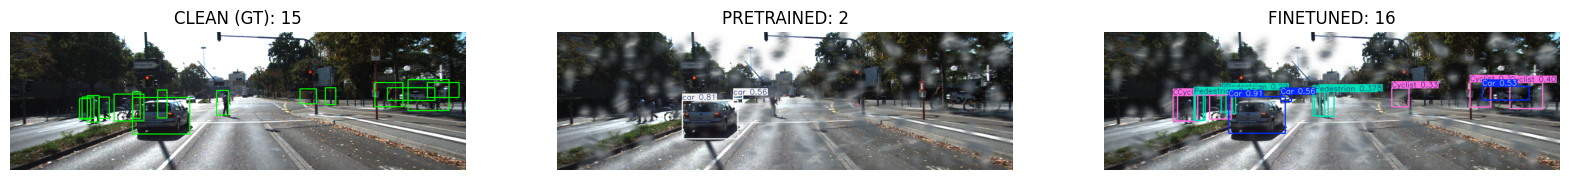

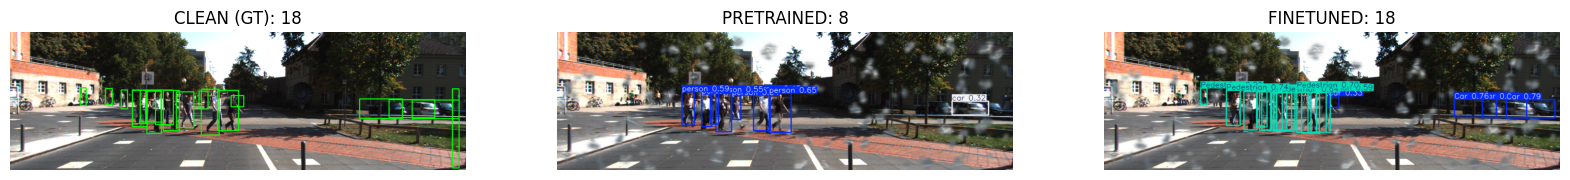

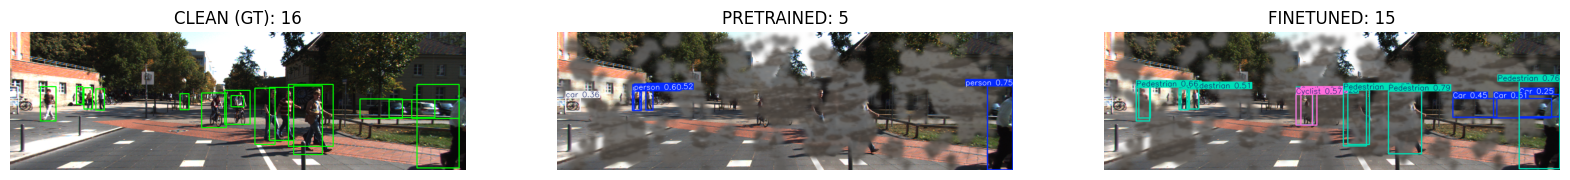

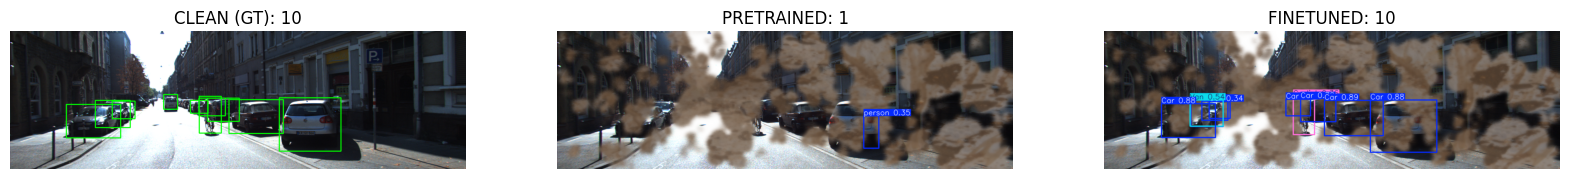

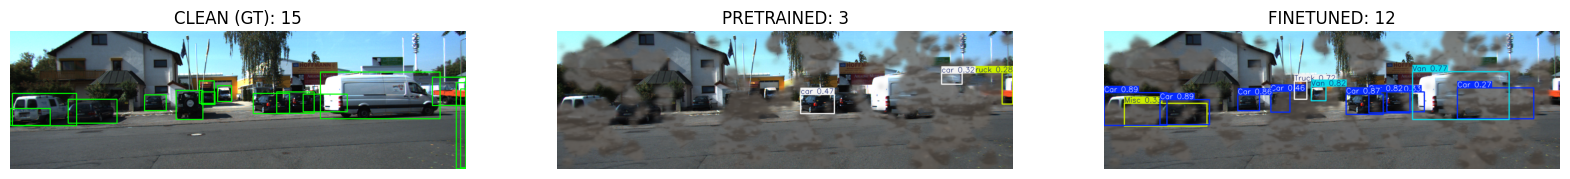


FINAL REPORT: GT vs PRETRAINED vs FINETUNED
Total Objects (GT Clean):       4055
Total Detections (Pretrained):  3459 | Loss: 14.70%
Total Detections (Finetuned):   4130 | Loss: -1.85%
------------------------------
Mean Confidence (GT Clean):      1.0000
Mean Confidence (Pretrained):    0.5278 | Drop: 47.22%
Mean Confidence (Finetuned):     0.6873 | Drop: 31.27%


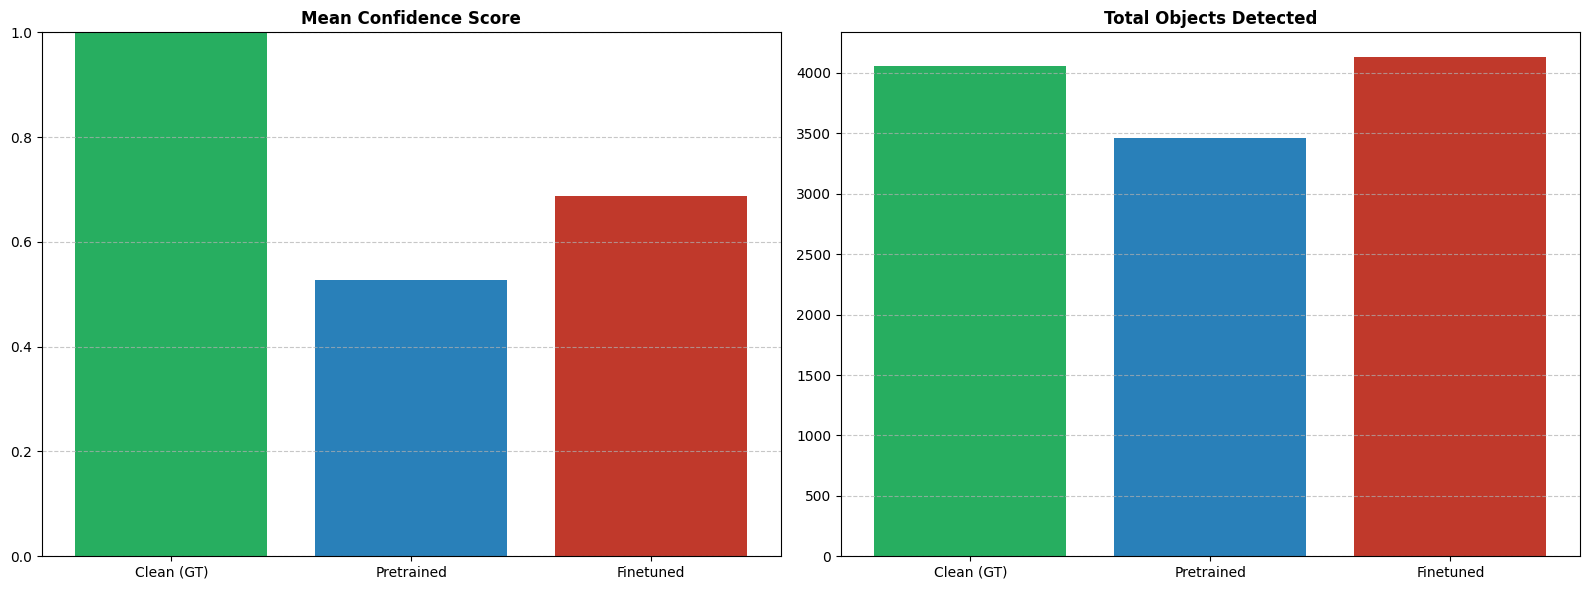

In [7]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================
# Helper: Draw GT boxes
# =========================
def draw_gt_boxes(image_path, label_path, class_filter=None):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    boxes = []

    if not os.path.exists(label_path):
        return img, boxes

    with open(label_path, 'r') as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())
            cls = int(cls)

            if class_filter is not None and cls not in class_filter:
                continue

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            boxes.append(cls)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return img, boxes

# =========================
# Setup: Load models
# =========================
pretrained_model = YOLO('../yolov8n.pt')
finetuned_model = YOLO(r"C:\Users\yuval\PycharmProjects\GenAI_Project\code\runs\detect\kitti_final_run\weights\best.pt")  # fine-tuned model

kitti_like_classes = [0, 1, 2, 3, 5, 7]

clean_img_dir = r"C:\Users\yuval\PycharmProjects\GenAI_Project\dataset\clean\images\test"
clean_lbl_dir = r"C:\Users\yuval\PycharmProjects\GenAI_Project\dataset\clean\labels\test"
dirty_dir = r"C:\Users\yuval\PycharmProjects\GenAI_Project\dataset\images\test"

dirty_images = glob.glob(os.path.join(dirty_dir, "*.png"))

max_samples = 5

# =========================
# Metrics & Sample Storage
# =========================
all_clean_confs, all_pretrained_confs, all_ft_confs = [], [], []
total_clean_objs, total_pretrained_objs, total_ft_objs = 0, 0, 0
improvement_samples = []

print(f"Analyzing {len(dirty_images)} images...")

# =========================
# Main Loop
# =========================
print(len(dirty_images))
for d_path in dirty_images:
    base_name = os.path.basename(d_path).split('_')[0]
    c_path = os.path.join(clean_img_dir, f"{base_name}.png")
    l_path = os.path.join(clean_lbl_dir, f"{base_name}.txt")

    if not os.path.exists(c_path):
        continue

    # --- CLEAN: GT only ---
    clean_img_gt, clean_boxes = draw_gt_boxes(c_path, l_path, class_filter=kitti_like_classes)
    c_confs = [1.0] * len(clean_boxes)
    total_clean_objs += len(clean_boxes)
    all_clean_confs.extend(c_confs)

    # --- DIRTY: Pretrained YOLO ---
    res_pretrained = pretrained_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]
    p_confs = res_pretrained.boxes.conf.cpu().numpy() if len(res_pretrained.boxes) > 0 else []
    total_pretrained_objs += len(res_pretrained.boxes)
    all_pretrained_confs.extend(p_confs)

    # --- DIRTY: Fine-tuned YOLO ---
    res_ft = finetuned_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]
    ft_confs = res_ft.boxes.conf.cpu().numpy() if len(res_ft.boxes) > 0 else []
    total_ft_objs += len(res_ft.boxes)
    all_ft_confs.extend(ft_confs)

    # --- Select images where pretrained < GT ---
    if len(res_pretrained.boxes) < len(clean_boxes):
        pretrained_error = abs(len(clean_boxes) - len(res_pretrained.boxes))
        ft_error = abs(len(clean_boxes) - len(res_ft.boxes))
        improvement = pretrained_error - ft_error

        improvement_samples.append({
            "clean_img": clean_img_gt,
            "pretrained_img": cv2.cvtColor(res_pretrained.plot(), cv2.COLOR_BGR2RGB),
            "ft_img": cv2.cvtColor(res_ft.plot(), cv2.COLOR_BGR2RGB),
            "clean_count": len(clean_boxes),
            "pretrained_count": len(res_pretrained.boxes),
            "ft_count": len(res_ft.boxes),
            "improvement": improvement
        })

# Sort and pick top 5
top_samples = sorted(improvement_samples, key=lambda x: x["improvement"], reverse=True)[:max_samples]

# =========================
# Display Top Improvement Samples
# =========================
for sample in top_samples:
    fig, ax = plt.subplots(1, 3, figsize=(20, 7))
    ax[0].imshow(sample["clean_img"])
    ax[0].set_title(f"CLEAN (GT): {sample['clean_count']}")
    ax[0].axis('off')

    ax[1].imshow(sample["pretrained_img"])
    ax[1].set_title(f"PRETRAINED: {sample['pretrained_count']}")
    ax[1].axis('off')

    ax[2].imshow(sample["ft_img"])
    ax[2].set_title(f"FINETUNED: {sample['ft_count']}")
    ax[2].axis('off')
    plt.show()

# =========================
# Compute Final Metrics
# =========================
mean_clean_conf = np.mean(all_clean_confs) if all_clean_confs else 0
mean_pretrained_conf = np.mean(all_pretrained_confs) if all_pretrained_confs else 0
mean_ft_conf = np.mean(all_ft_confs) if all_ft_confs else 0

pretrained_obj_loss_pct = ((total_clean_objs - total_pretrained_objs) / total_clean_objs) * 100 if total_clean_objs > 0 else 0
ft_obj_loss_pct = ((total_clean_objs - total_ft_objs) / total_clean_objs) * 100 if total_clean_objs > 0 else 0

pretrained_conf_drop_pct = ((mean_clean_conf - mean_pretrained_conf) / mean_clean_conf) * 100 if mean_clean_conf > 0 else 0
ft_conf_drop_pct = ((mean_clean_conf - mean_ft_conf) / mean_clean_conf) * 100 if mean_clean_conf > 0 else 0

print("\n" + "="*50)
print("FINAL REPORT: GT vs PRETRAINED vs FINETUNED")
print("="*50)
print(f"Total Objects (GT Clean):       {total_clean_objs}")
print(f"Total Detections (Pretrained):  {total_pretrained_objs} | Loss: {pretrained_obj_loss_pct:.2f}%")
print(f"Total Detections (Finetuned):   {total_ft_objs} | Loss: {ft_obj_loss_pct:.2f}%")
print("-"*30)
print(f"Mean Confidence (GT Clean):      {mean_clean_conf:.4f}")
print(f"Mean Confidence (Pretrained):    {mean_pretrained_conf:.4f} | Drop: {pretrained_conf_drop_pct:.2f}%")
print(f"Mean Confidence (Finetuned):     {mean_ft_conf:.4f} | Drop: {ft_conf_drop_pct:.2f}%")
print("="*50)

# =========================
# Final Plot: GT vs Pretrained vs Fine-tuned
# =========================
labels = ['Clean (GT)', 'Pretrained', 'Finetuned']
conf_vals = [mean_clean_conf, mean_pretrained_conf, mean_ft_conf]
obj_vals = [total_clean_objs, total_pretrained_objs, total_ft_objs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(labels, conf_vals, color=['#27ae60', '#2980b9', '#c0392b'])
ax1.set_title('Mean Confidence Score', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.bar(labels, obj_vals, color=['#27ae60', '#2980b9', '#c0392b'])
ax2.set_title('Total Objects Detected', fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [8]:
# =========================
# Additional Evaluation Metrics
# =========================
def compute_iou(box1, box2):
    """
    box = [x1, y1, x2, y2]
    Returns IoU between two boxes
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0

def get_boxes_from_yolo(yolo_result):
    """
    Converts YOLOv8 results to [x1, y1, x2, y2] list
    """
    if len(yolo_result.boxes) == 0:
        return []
    boxes = yolo_result.boxes.xyxy.cpu().numpy()
    return boxes.tolist()

# IoU threshold for considering a detection correct
iou_threshold = 0.5

# Store overall metrics
all_precisions, all_recalls, all_f1s = [], [], []

for d_path in dirty_images:
    base_name = os.path.basename(d_path).split('_')[0]
    c_path = os.path.join(clean_img_dir, f"{base_name}.png")
    l_path = os.path.join(clean_lbl_dir, f"{base_name}.txt")

    if not os.path.exists(c_path):
        continue

    # --- GT boxes ---
    _, clean_boxes_cls = draw_gt_boxes(c_path, l_path, class_filter=kitti_like_classes)

    # Load GT boxes in [x1,y1,x2,y2] format
    clean_boxes_coords = []
    with open(l_path, 'r') as f:
        img = cv2.imread(c_path)
        h, w, _ = img.shape
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())
            cls = int(cls)
            if cls not in kitti_like_classes:
                continue
            x1 = int((xc - bw/2)*w)
            y1 = int((yc - bh/2)*h)
            x2 = int((xc + bw/2)*w)
            y2 = int((yc + bh/2)*h)
            clean_boxes_coords.append([x1, y1, x2, y2])

    # --- Predictions ---
    res_ft = finetuned_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]
    res_pretrained = pretrained_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]

    ft_boxes = get_boxes_from_yolo(res_ft)
    pt_boxes = get_boxes_from_yolo(res_pretrained)

    # Function to compute precision/recall
    def compute_pr(pred_boxes, gt_boxes, iou_thresh):
        matched_gt = set()
        TP = 0
        for pb in pred_boxes:
            for i, gb in enumerate(gt_boxes):
                if i in matched_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou >= iou_thresh:
                    TP += 1
                    matched_gt.add(i)
                    break
        FP = len(pred_boxes) - TP
        FN = len(gt_boxes) - TP
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        return precision, recall, f1

    # Compute metrics
    ft_prec, ft_rec, ft_f1 = compute_pr(ft_boxes, clean_boxes_coords, iou_threshold)
    pt_prec, pt_rec, pt_f1 = compute_pr(pt_boxes, clean_boxes_coords, iou_threshold)

    all_precisions.append([pt_prec, ft_prec])
    all_recalls.append([pt_rec, ft_rec])
    all_f1s.append([pt_f1, ft_f1])

# Convert to numpy arrays for easier computation
all_precisions = np.array(all_precisions)
all_recalls = np.array(all_recalls)
all_f1s = np.array(all_f1s)

# Average across all images
avg_prec = np.mean(all_precisions, axis=0)
avg_rec = np.mean(all_recalls, axis=0)
avg_f1 = np.mean(all_f1s, axis=0)

print("\n" + "="*50)
print("ADDITIONAL METRICS: PRETRAINED vs FINETUNED")
print("="*50)
print(f"Precision:   Pretrained: {avg_prec[0]:.4f} | Finetuned: {avg_prec[1]:.4f}")
print(f"Recall:      Pretrained: {avg_rec[0]:.4f} | Finetuned: {avg_rec[1]:.4f}")
print(f"F1 Score:    Pretrained: {avg_f1[0]:.4f} | Finetuned: {avg_f1[1]:.4f}")
print("="*50)



ADDITIONAL METRICS: PRETRAINED vs FINETUNED
Precision:   Pretrained: 0.5857 | Finetuned: 0.8418
Recall:      Pretrained: 0.5333 | Finetuned: 0.8410
F1 Score:    Pretrained: 0.5297 | Finetuned: 0.8262
